In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append('C:/Users/fgarchitorena/OpenFast/Design Load Cases/openfast_toolbox-main/')

from scipy.interpolate import LinearNDInterpolator
from openfast_toolbox.io import FASTOutputFile

In [3]:
plt.figure(figsize=(10, 5))
plt.rcParams.update({
    "text.usetex": False,
    "font.family": 'serif',
    "font.serif": ['Times New Roman'],
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 12,            # Tamaño general de la fuente
    "axes.titlesize": 16,       # Tamaño de la fuente para el título de los ejes
    "axes.labelsize": 14,       # Tamaño de la fuente para las etiquetas de los ejes
    "xtick.labelsize": 12,      # Tamaño de la fuente para las etiquetas de los ticks en el eje x
    "ytick.labelsize": 12,      # Tamaño de la fuente para las etiquetas de los ticks en el eje y
    "legend.fontsize": 12,      # Tamaño de la fuente para la leyenda
    "figure.titlesize": 16      # Tamaño de la fuente para el título de la figura
})

<Figure size 1000x500 with 0 Axes>

In [4]:
variables = ['RootMxb1_[kN-m]','RootMyb1_[kN-m]', 'TwrBsMyt_[kN-m]', 'TwrBsMxt_[kN-m]', 'LSSGagMya_[kN-m]', 'LSSGagMza_[kN-m]']
varnames = ['EdgeWise','FlapWise', 'ForeAft', 'SideSide','LSSGagMya', 'LSSGagMza']
m_values = {
    'LSSGagMya_[kN-m]': 4, 
    'LSSGagMza_[kN-m]': 4, 
    'TwrBsMxt_[kN-m]': 4, 
    'TwrBsMyt_[kN-m]': 4,
    'GenTq_[kN-m]': 4
}

for i in range(1, 3):
    m_values[f'RootMxb{i}_[kN-m]'] = 10
    m_values[f'RootMyb{i}_[kN-m]'] = 10



===== Comparación de DELs =====
           Variable      DEL_base      DEL_Wang  Aumento_pct
0   RootMxb1_[kN-m]   4597.357263   4580.208379    -0.373016
1   RootMyb1_[kN-m]   2597.345550   3405.279422    31.106137
2   TwrBsMyt_[kN-m]  11961.266914  13587.209238    13.593396
3   TwrBsMxt_[kN-m]   7215.281924   7230.482330     0.210670
4  LSSGagMya_[kN-m]   1193.840008   1177.344686    -1.381703
5  LSSGagMza_[kN-m]   1219.037795   1196.667271    -1.835097

===== Comparación de Valores Máximos =====
           Variable      Max_base      Max_Wang   Aumento_pct
0   RootMxb1_[kN-m]   3684.588607   3659.371025 -6.844070e-01
1   RootMyb1_[kN-m]   8661.305223   8661.305223  0.000000e+00
2   TwrBsMyt_[kN-m]  63881.590692  63881.590692  0.000000e+00
3   TwrBsMxt_[kN-m]  11325.774676  11325.774676  0.000000e+00
4  LSSGagMya_[kN-m]   1382.985505   1382.985505  0.000000e+00
5  LSSGagMza_[kN-m]   1523.034939   1523.034934 -3.798373e-07


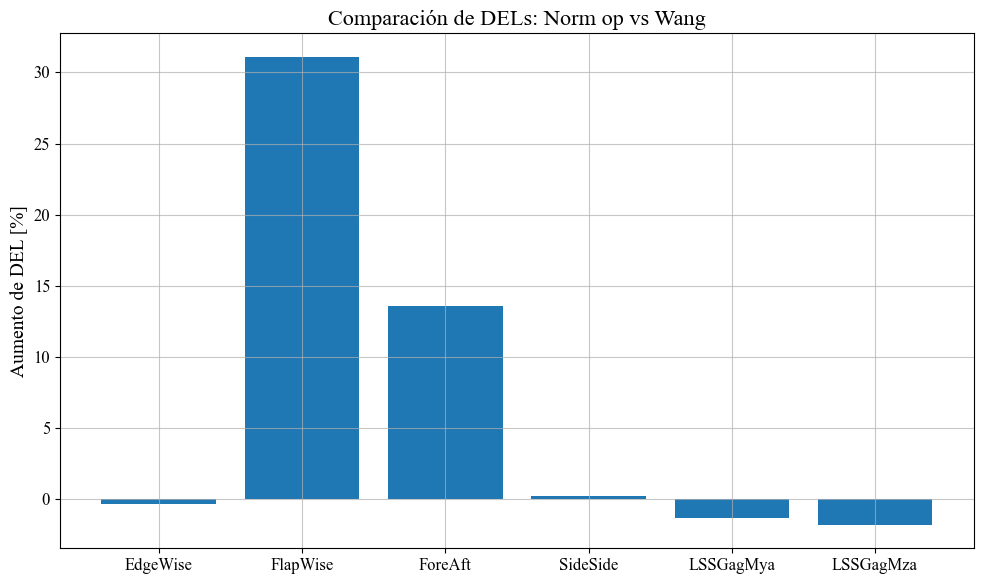

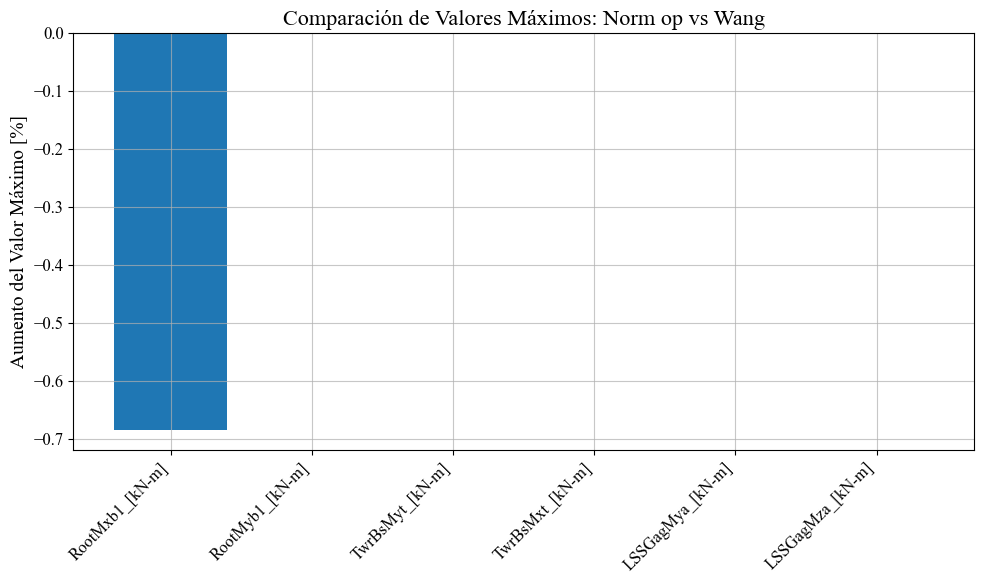

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from getSimRes import *  # tu función original

Turbine = "IEA_3p4MW"#"NREL5MW"
Wind_Condition = "v8_TI10"
turbine_base_name = "IEA-3.4-130-RWT"#"NRELOffshrBsline5MW"   

# Simulaciones a procesar
simulations = [
    f"C:/Users/fgarchitorena/Proyectos_de_investigacion/FSE_Incercia_Sintetica/Controladores-IS-ROSCO/Test_Wang_OF/{Turbine}/{Wind_Condition}/{turbine_base_name}_norm_op_{Wind_Condition}.outb",
    f"C:/Users/fgarchitorena/Proyectos_de_investigacion/FSE_Incercia_Sintetica/Controladores-IS-ROSCO/Test_Wang_OF/{Turbine}/{Wind_Condition}/{turbine_base_name}_Wang_{Wind_Condition}.outb"
]

simulations_names = [
    "Normal Operation",
    "Wang"
]

# Variables y parámetros
Teq = 1.0
bins = 100
nbins = bins

# Columnas para el DataFrame
columns = ["Simulation Name", "Leq"] + \
          [f"S_{i}" for i in range(1, nbins + 1)] + \
          [f"N_{i}" for i in range(1, nbins + 1)]

# Diccionario para resultados
resultados = {sim: {var: None for var in variables} for sim in simulations_names}
maximos = {sim: {} for sim in simulations_names}   # <<< NEW >>>

# Procesar cada simulación y variable
for i, simName in enumerate(simulations):
    for var in variables:
        m = m_values[var]

        # Para estas simulaciones sacamos todo el rango de tiempo
        start_index = int(60/0.00625)
        end_index = int(660/0.00625)  

        # tu función devuelve más cosas, ahora también usamos el máximo
       # tu función devuelve más cosas, pero acá usamos solo lo necesario
        result, max_var_value = getSimRes(
            simName, var, m, Teq, bins,
            start_index, end_index
        )
        Leq, S, N, *_ = result


        # Guardar en DataFrame de resultados de DELs
        df = pd.DataFrame(
            [[simulations_names[i], Leq] + list(S) + list(N)],
            columns=columns
        )
        resultados[simulations_names[i]][var] = df

        # Guardar valor máximo
        maximos[simulations_names[i]][var] = max_var_value   # <<< NEW >>>

# =========================================================
# Construir tabla comparativa de DELs para cada variable
# =========================================================
tabla_resultados = []

for var in variables:
    base_Leq = resultados[simulations_names[0]][var]["Leq"].values[0]
    wang_Leq = resultados[simulations_names[1]][var]["Leq"].values[0]
    aumento_pct = 100 * (wang_Leq - base_Leq) / base_Leq

    tabla_resultados.append([var, base_Leq, wang_Leq, aumento_pct])

tabla_df = pd.DataFrame(tabla_resultados,
                        columns=["Variable", "DEL_base", "DEL_Wang", "Aumento_pct"])

print("\n===== Comparación de DELs =====")
print(tabla_df)

# =========================================================
# Construir tabla comparativa de valores máximos
# =========================================================
tabla_maximos = []

for var in variables:
    base_max = maximos[simulations_names[0]][var]
    wang_max = maximos[simulations_names[1]][var]
    aumento_pct_max = 100 * (wang_max - base_max) / base_max

    tabla_maximos.append([var, base_max, wang_max, aumento_pct_max])

tabla_max_df = pd.DataFrame(tabla_maximos,
                            columns=["Variable", "Max_base", "Max_Wang", "Aumento_pct"])

print("\n===== Comparación de Valores Máximos =====")
print(tabla_max_df)

# =========================================================
# Gráfico de barras del aumento porcentual DEL
# =========================================================
plt.figure(figsize=(10, 6))
plt.bar(varnames, tabla_df["Aumento_pct"])
plt.xticks(rotation=0, ha="center")
plt.ylabel("Aumento de DEL [%]")
plt.title("Comparación de DELs: Norm op vs Wang")
plt.grid(alpha=0.7)
plt.tight_layout()
plt.show()

# =========================================================
# Gráfico de barras del aumento porcentual de máximos
# =========================================================
plt.figure(figsize=(10, 6))
plt.bar(tabla_max_df["Variable"], tabla_max_df["Aumento_pct"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Aumento del Valor Máximo [%]")
plt.title("Comparación de Valores Máximos: Norm op vs Wang")
plt.grid(alpha=0.7)
plt.tight_layout()
plt.show()



===== Energía inyectada tras aplicar inercia sintética =====
  Simulación  Duración [s]  Energía [kWh]
0    norm_op           5.0       2.205314
1    norm_op          10.0       4.472844
2  Tarnowski           5.0       2.928384
3  Tarnowski          10.0       5.891255
4       Wang           5.0       3.332921
5       Wang          10.0       5.698289


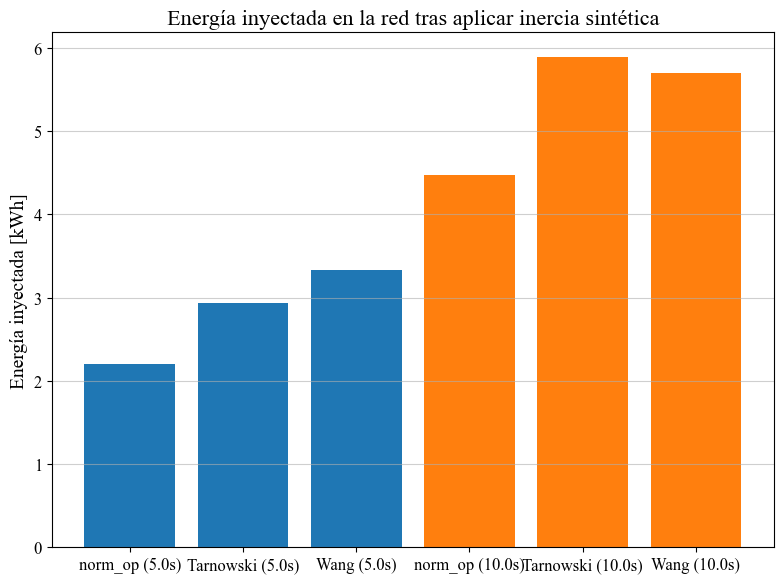

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openfast_toolbox.io import FASTOutputFile  # Asegurate que este import funciona

# Parámetros
Turbine = "IEA_3p4MW"  # o "NREL5MW"
Wind_Condition = "v8_TI10"
turbine_base_name = "IEA-3.4-130-RWT"  # o "NRELOffshrBsline5MW"

# # Simulaciones a procesar
# simulations = [
#     f"C:/Users/fgarchitorena/Proyectos_de_investigacion/FSE_Incercia_Sintetica/Controladores-IS-ROSCO/Test_Wang_OF/{Turbine}/{Wind_Condition}/{turbine_base_name}_norm_op_{Wind_Condition}.outb",
#     f"C:/Users/fgarchitorena/Proyectos_de_investigacion/FSE_Incercia_Sintetica/Controladores-IS-ROSCO/Test_Wang_OF/{Turbine}/{Wind_Condition}/{turbine_base_name}_Wang_{Wind_Condition}.outb"
# ]

# simulations_names = [
#     "Normal Operation",
#     "Wang"
# ]

simulations = [
    f"C:/Users/fgarchitorena/Proyectos_de_investigacion/FSE_Incercia_Sintetica/Controladores-IS-ROSCO/Test_Wang_OF/{Turbine}/{Wind_Condition}/{turbine_base_name}_norm_op_{Wind_Condition}.outb",
    f"C:/Users/fgarchitorena/Proyectos_de_investigacion/FSE_Incercia_Sintetica/Controladores-IS-ROSCO/Test_Tarnowski_OF/{Turbine}/{Wind_Condition}/{turbine_base_name}_Tarnowski_{Wind_Condition}.outb",
   # f"C:/Users/fgarchitorena/Proyectos_de_investigacion/FSE_Incercia_Sintetica/Controladores-IS-ROSCO/Test_Ontario_OF/{Turbine}/{Wind_Condition}/{turbine_base_name}_Ontario_{Wind_Condition}.outb",
    f"C:/Users/fgarchitorena/Proyectos_de_investigacion/FSE_Incercia_Sintetica/Controladores-IS-ROSCO/Test_Wang_OF/{Turbine}/{Wind_Condition}/{turbine_base_name}_Wang_{Wind_Condition}.outb"
]

simulations_names = [
    "norm_op",
    "Tarnowski",
#    "Ontario",
    "Wang"
]

# Tiempo de inicio de la inercia sintética
t_inercia = 360.0  # [s]
duraciones = [5.0, 10.0]  # [s]

# Resultados
resultados = []

for simName, label in zip(simulations, simulations_names):
    # Leer archivo de simulación
    df = FASTOutputFile(simName).toDataFrame()
    time = np.array(df['Time_[s]'])
    GenPwr = np.array(df['GenPwr_[kW]'])

    # Para cada duración, calcular la energía inyectada
    for dur in duraciones:
        t_start = t_inercia
        t_end = t_inercia + dur

        # Índices en ese rango
        mask = (time >= t_start) & (time <= t_end)
        t_segment = time[mask]
        P_segment = GenPwr[mask]

        # Integrar con trapz (resultado en kW*s = kJ)
        E_kWs = np.trapz(P_segment, t_segment)  # kW·s = kJ
        E_kWh = E_kWs / 3600.0  # convertir a kWh

        resultados.append([label, dur, E_kWh])

# Pasar a DataFrame para tabla ordenada
tabla = pd.DataFrame(resultados, columns=["Simulación", "Duración [s]", "Energía [kWh]"])

print("\n===== Energía inyectada tras aplicar inercia sintética =====")
print(tabla)

# =====================================================
# Gráfico de barras comparando energía en kWh
# =====================================================
plt.figure(figsize=(8,6))

for dur in duraciones:
    subset = tabla[tabla["Duración [s]"] == dur]
    plt.bar(subset["Simulación"] + f" ({dur}s)", subset["Energía [kWh]"])

plt.ylabel("Energía inyectada [kWh]")
plt.title("Energía inyectada en la red tras aplicar inercia sintética")
plt.grid(axis="y", alpha=0.6)
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from getSimRes import *  # tu función original

Turbine = "IEA_3p4MW"
# Simulaciones a procesar
simulations = [
    f"C:/Users/fgarchitorena/Proyectos_de_investigacion/FSE_Incercia_Sintetica/Controladores-IS-ROSCO/Test_Wang_OF/{Turbine}/v8_TI10/IEA-3.4-130-RWT_norm_op.outb",
    f"C:/Users/fgarchitorena/Proyectos_de_investigacion/FSE_Incercia_Sintetica/Controladores-IS-ROSCO/Test_Tarnowski_OF/{Turbine}/IEA-3.4-130-RWT_Tarnowski.outb",
   # f"C:/Users/fgarchitorena/Proyectos_de_investigacion/FSE_Incercia_Sintetica/Controladores-IS-ROSCO/Test_Ontario_OF/{Turbine}/IEA-3.4-130-RWT_Ontario.outb",
    f"C:/Users/fgarchitorena/Proyectos_de_investigacion/FSE_Incercia_Sintetica/Controladores-IS-ROSCO/Test_Wang_OF/{Turbine}/IEA-3.4-130-RWT_Wang.outb"
]

simulations_names = [
    "norm_op",
    "Tarnowski",
#    "Ontario",
    "Wang"
]

# Variables y parámetros
Teq = 1.0
bins = 100
nbins = bins

# Columnas para el DataFrame
columns = ["Simulation Name", "Leq"] + \
          [f"S_{i}" for i in range(1, nbins + 1)] + \
          [f"N_{i}" for i in range(1, nbins + 1)]

# Diccionarios para resultados
resultados = {sim: {var: None for var in variables} for sim in simulations_names}
maximos = {sim: {} for sim in simulations_names}

# Procesar cada simulación y variable
for i, simName in enumerate(simulations):
    for var in variables:
        m = m_values[var]
        start_index = int(60/0.00625)
        end_index = int(660/0.00625)

        # Obtener DEL y valor máximo
        result, max_var_value = getSimRes(
            simName, var, m, Teq, bins,
            start_index, end_index
        )
        Leq, S, N, *_ = result

        # Guardar en DataFrame
        df = pd.DataFrame([[simulations_names[i], Leq] + list(S) + list(N)], columns=columns)
        resultados[simulations_names[i]][var] = df

        # Guardar valor máximo
        maximos[simulations_names[i]][var] = max_var_value

# =========================================================
# Tabla comparativa de DELs y gráficos
# =========================================================
tabla_dels = []

for var in variables:
    base_Leq = resultados["norm_op"][var]["Leq"].values[0]
    fila = [var, base_Leq]
    for strat in ["Tarnowski", "Ontario", "Wang"]:
        Leq_strat = resultados[strat][var]["Leq"].values[0]
        aumento_pct = 100 * (Leq_strat - base_Leq) / base_Leq
        fila += [Leq_strat, aumento_pct]
    tabla_dels.append(fila)

columnas_dels = ["Variable", "DEL_norm_op",
                 "DEL_Tarnowski", "Aumento_Tarnowski_%", 
                 "DEL_Ontario", "Aumento_Ontario_%", 
                 "DEL_Wang", "Aumento_Wang_%"]

tabla_dels_df = pd.DataFrame(tabla_dels, columns=columnas_dels)
print("\n===== Comparación de DELs =====")
print(tabla_dels_df)

# Gráfico DELs
plt.figure(figsize=(12,6))
x = range(len(variables))
plt.bar(x, tabla_dels_df["Aumento_Tarnowski_%"], width=0.2, label="Tarnowski")
plt.bar([i+0.2 for i in x], tabla_dels_df["Aumento_Ontario_%"], width=0.2, label="Ontario")
plt.bar([i+0.4 for i in x], tabla_dels_df["Aumento_Wang_%"], width=0.2, label="Wang")
plt.xticks([i+0.2 for i in x], variables, rotation=45, ha="right")
plt.ylabel("Aumento de DEL [%]")
plt.title("Comparación de DELs respecto a norm_op")
plt.legend()
plt.grid(alpha=0.7)
plt.tight_layout()
plt.show()

# =========================================================
# Tabla comparativa de máximos y gráfico
# =========================================================
tabla_maximos = []

for var in variables:
    base_max = maximos["norm_op"][var]
    fila = [var, base_max]
    for strat in ["Tarnowski", "Ontario", "Wang"]:
        max_strat = maximos[strat][var]
        aumento_pct = 100 * (max_strat - base_max) / base_max
        fila += [max_strat, aumento_pct]
    tabla_maximos.append(fila)

columnas_max = ["Variable", "Max_norm_op",
                "Max_Tarnowski", "Aumento_Tarnowski_%", 
                "Max_Ontario", "Aumento_Ontario_%", 
                "Max_Wang", "Aumento_Wang_%"]

tabla_max_df = pd.DataFrame(tabla_maximos, columns=columnas_max)
print("\n===== Comparación de Valores Máximos =====")
print(tabla_max_df)

# Gráfico máximos
plt.figure(figsize=(12,6))
plt.bar(x, tabla_max_df["Aumento_Tarnowski_%"], width=0.2, label="Tarnowski")
plt.bar([i+0.2 for i in x], tabla_max_df["Aumento_Ontario_%"], width=0.2, label="Ontario")
plt.bar([i+0.4 for i in x], tabla_max_df["Aumento_Wang_%"], width=0.2, label="Wang")
plt.xticks([i+0.2 for i in x], variables, rotation=45, ha="right")
plt.ylabel("Aumento del Valor Máximo [%]")
plt.title("Comparación de Valores Máximos respecto a norm_op")
plt.legend()
plt.grid(alpha=0.7)
plt.tight_layout()
plt.show()

No results


ValueError: too many values to unpack (expected 2)

In [ ]:
# Get OpenFAST data - Carpeta D:/Leandro/OpenFast/proyecto_IEA/corridas/09-10-2023/
model = '1p1'  # flexible; rigid
U = '8.0'
sd = 'sd0'
tech = ''#'_ROSCO_SDTime'#'_TurbS'#'_prueba_ROSCO'#'_PM' ##'prueba_encendido'#'_ROSCO_SDTime_'#_PitchMan'#'_ROSCO_TurbS_'  #'_PM_'#   #'ROSCO_TurbS'#'PM_SinGen'
tech_f = ''#'_ROSCO_SDTime'#'_PM'#'ROSCO_TurbS' #'2p1_PM'#

folder = f'C:/Users/fgarchitorena/Proyectos de i/OpenFast/DLCs_post_pro/DLC_{model[0]}/{model}{tech}/{U}/{sd}'
print(folder)

filename = f'IEA-3.4-130-RWT_{model}_{U}_{sd}.outb'#'_RTS
#filename = f'IEA-3.4-130-RWT_{model}{tech}{U}.outb'#'_RTS
#filename = f'NRELOffshrBsline5MW_{model}_{U}_{sd}.outb'#'_RTS

df = FASTOutputFile(folder +'/' + filename).toDataFrame()
time = np.array(list(df['Time_[s]']))


# Define el intervalo de tiempo útil
dt = 0.00625  # Intervalo de tiempo
start_index = int(60 / dt)  # Convierte 60 segundos a índices
end_index = len(time)  # O define hasta dónde quieres seleccionar

# Selecciona el tiempo útil
Useful_time_1 = time[start_index:end_index]
RotPwr_1 = np.array(list(df['RotPwr_[kW]']))
GenPwr_1 = np.array(list(df['GenPwr_[kW]']))
RotSpeed_1 = np.array(list(df['RotSpeed_[rpm]']))
BldPitch1_1 = np.array(list(df['BldPitch1_[deg]']))
Edgewise_1 = np.array(list(df['RootMxb1_[kN-m]']))
Flapwise1 = np.array(list(df['RootMyb1_[kN-m]']))
Foreaft1 = np.array(list(df['TwrBsMyt_[kN-m]']))
SideSide1 = np.array(list(df['TwrBsMxt_[kN-m]']))
RotTorq = np.array(list(df['RotTorq_[kN-m]']))
#LSSTipPxs = np.array(list(df['LSSTipPxs_[deg]'])) 
Gentq = np.array(list(df['GenTq_[kN-m]']))
GenSpeed = np.array(list(df['GenSpeed_[rpm]']))
#Wind1VelX = np.array(list(df['Wind1VelX_[m/s]']))
#WindHubVelX = np.array(list(df['WindHubVelX_[m/s]']))
#WindHubVelY = np.array(list(df['WindHubVelY_[m/s]']))
#WindHubVelZ = np.array(list(df['WindHubVelZ_[m/s]']))


#print(Useful_time_1)

directorio_save = f'C:/Users/fgarchitorena/Desktop/Imagenes_DLCs_2/{model}{tech_f}/{U}/'# Cambia esto a la ruta deseada
print(directorio_save)
                    #----


C:/Users/fgarchitorena/Proyectos de i/OpenFast/DLCs_post_pro/DLC_1/1p1/8.0/sd0


FileNotFoundError: [Errno 2] File not found:: 'C:/Users/fgarchitorena/Proyectos de i/OpenFast/DLCs_post_pro/DLC_1/1p1/8.0/sd0/IEA-3.4-130-RWT_1p1_8.0_sd0.outb'

Potencia aerodinámica media: 2112.9737008214033
Potencia generada media: 1981.6763200620833


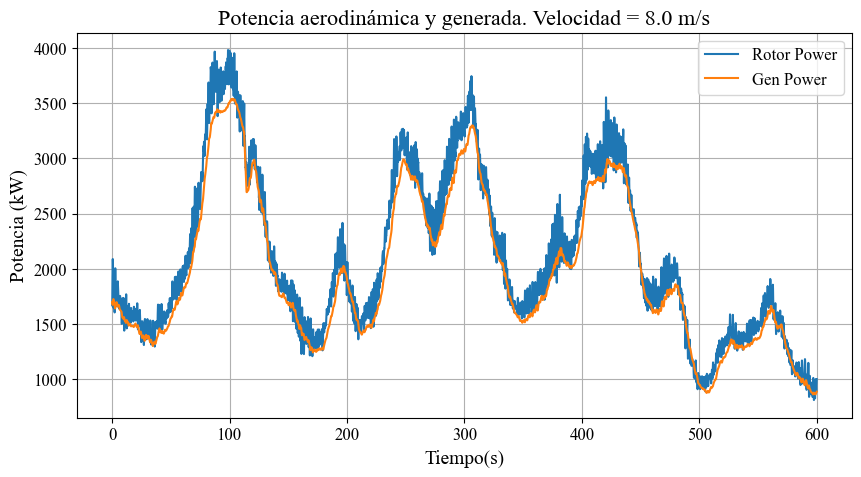

In [ ]:
#PLOTS
  
varName_1 = 'RotPwr_[kW]'
varName_2 = 'GenPwr_[kW]'

plt.figure(figsize=(10, 5))
plt.plot(Useful_time_1-60, RotPwr_1[start_index:end_index], '-', markersize = 12, label='Rotor Power')
plt.plot(Useful_time_1-60, GenPwr_1[start_index:end_index], '-', markersize = 12, label='Gen Power')
Pot_media_rot = np.mean(RotPwr_1[start_index:end_index])
Pot_media_gen = np.mean(GenPwr_1[start_index:end_index])
print('Potencia aerodinámica media:',Pot_media_rot )
print('Potencia generada media:',Pot_media_gen )
plt.xlabel('Tiempo(s)')#,**hfont)
plt.ylabel('Potencia (kW)')#,**hfont)
plt.title(f'Potencia aerodinámica y generada. Velocidad = {U} m/s')#,**hfont)
plt.grid()
#plt.xlim(290,325)#plt.xlim(2000,2090)
plt.legend()
#plt.axvline(300, color='black', linestyle='--', linewidth=2)
#plt.axvline(400, color='black', linestyle='--', linewidth=2)
#plt.text(450, max(max(RotPwr_1[start_index:end_index]), max(GenPwr_1[start_index:end_index])) / 2, 
#         "ventana 3", fontsize=14, color='black', ha='center', va='center', 
#         bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
plt.locator_params(axis='both', nbins=10)
#filename = f'Pot_{model}{tech}_{U}_mas_zoom.png'
filename = f'Pot_{model}{tech}_{U}_con_lims_v3_100.png'
#directorio_save = f'C:/Users/fgarchitorena/Desktop/Imagenes_DLCs_2/{model}{tech_f}/{U}/'# Cambia esto a la ruta deseada
directorio_save = f'C:/Users/fgarchitorena/Desktop/Imagenes_DLCs_2/post_pro/'# Cambia esto a la ruta deseada
file_path = os.path.join(directorio_save, filename)
#plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
plt.show()

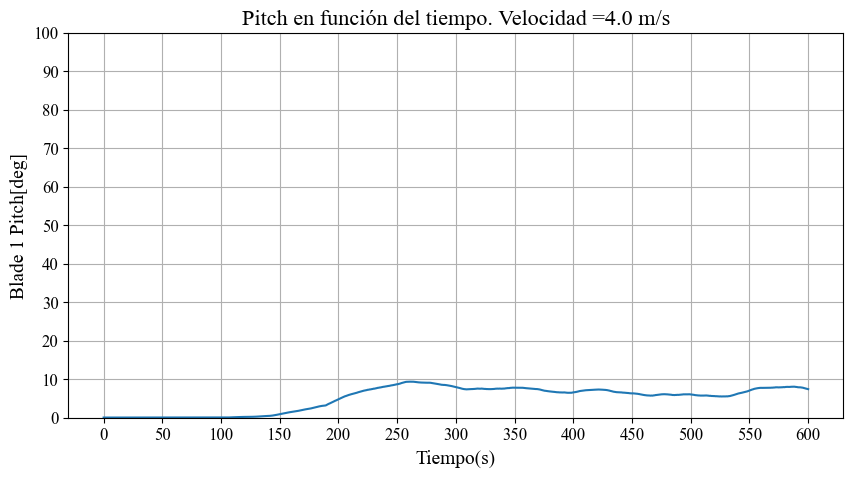

In [ ]:
var = BldPitch1_1
varName = 'Blade 1 Pitch[deg]'
xlim_3p1_zoom = [1750,2250]
plt.figure(figsize=(10, 5))
plt.plot(Useful_time_1-60, var[start_index:end_index], '-', markersize = 12)
plt.xlabel('Tiempo(s)')
plt.ylabel(varName)
plt.title(f'Pitch en función del tiempo. Velocidad ={U} m/s')
plt.grid()
plt.ylim(0,100)
#plt.xlim(xlim_3p1_zoom)
plt.locator_params(axis='both', nbins=15)
filename = 'Pitch_'+ model +tech +U+'.png'
file_path = os.path.join(directorio_save, filename)
#plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
plt.show()

In [ ]:
var = WindHubVelX
varName = 'Velocidad Hub [m/s]'
plt.figure(figsize=(10, 5))
plt.plot(Useful_time_1-60, var[start_index:end_index], '-', markersize = 12)
plt.xlabel('Tiempo(s)')
plt.ylabel(varName)
plt.title(f'Velocidad de viento en altura de buje. Velocidad media ={U} m/s')
plt.grid()
plt.xlim(0,600)
plt.locator_params(axis='both', nbins=15)
filename = 'V_Hub_'+ model +tech +U+'.png'
file_path = os.path.join(directorio_save, filename)
#plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
plt.show()
TI = np.std(var)/ np.mean(var)
print(TI)

NameError: name 'WindHubVelX' is not defined

[1.1730561  1.1730561  1.04169714 ... 7.37662582 7.37648304 7.37619748]


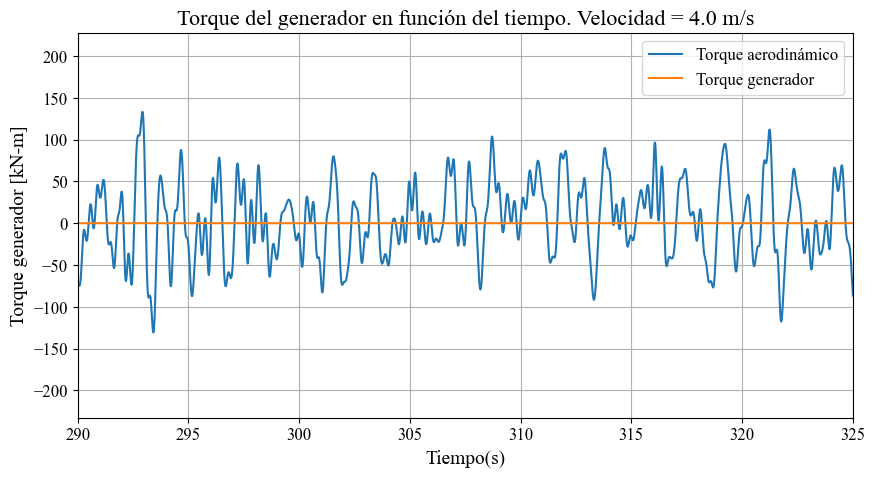

In [ ]:
var = Gentq
print(BldPitch1_1)
varName = 'Torque generador [kN-m]'

plt.figure(figsize=(10, 5))
plt.plot(Useful_time_1-60, RotTorq[start_index:end_index], '-', markersize = 12, label = 'Torque aerodinámico')
plt.plot(Useful_time_1-60, var[start_index:end_index]*97, '-', markersize = 12, label = 'Torque generador')
plt.xlabel('Tiempo(s)')
plt.ylabel(varName)
plt.title(f'Torque del generador en función del tiempo. Velocidad = {U} m/s')
plt.grid()
plt.legend()
plt.xlim(290,325)#
#plt.xlim(2000,2090)
plt.locator_params(axis='both', nbins=10)
filename = f'Torques_{model}{tech}_{U}_mas_zoom.png'
file_path = os.path.join(directorio_save, filename)
#plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
plt.show()

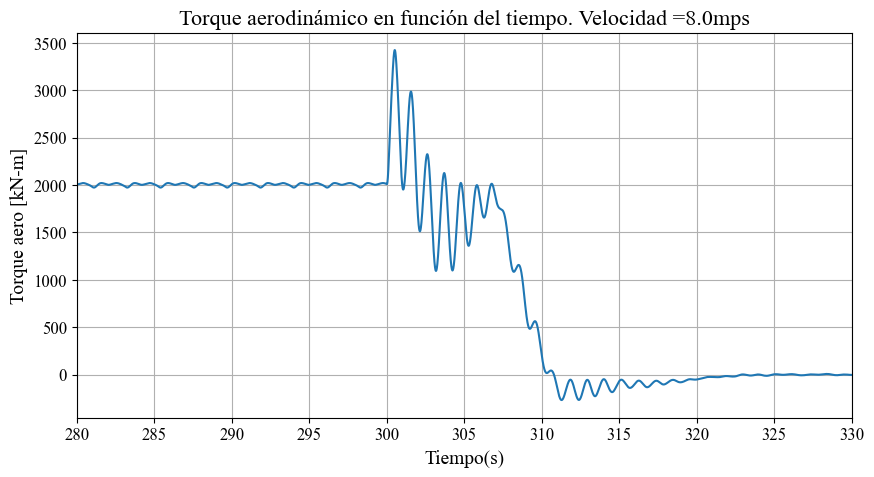

In [ ]:
var = RotTorq
varName = 'Torque aero [kN-m]'

plt.figure(figsize=(10, 5))
plt.plot(Useful_time_1-60, var[start_index:end_index], '-', markersize = 12)
plt.xlabel('Tiempo(s)')
plt.ylabel(varName)
plt.title(f'Torque aerodinámico en función del tiempo. Velocidad ={U}mps')
plt.grid()
plt.xlim(280,330)
plt.locator_params(axis='both', nbins=15)
filename = 'Pitch_'+ model +tech +U+'.png'
file_path = os.path.join(directorio_save, filename)
#plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
plt.show()

[ 487.32498501  486.98803653  487.29435333 ... 1117.22464712 1117.22464712
 1117.22464712]


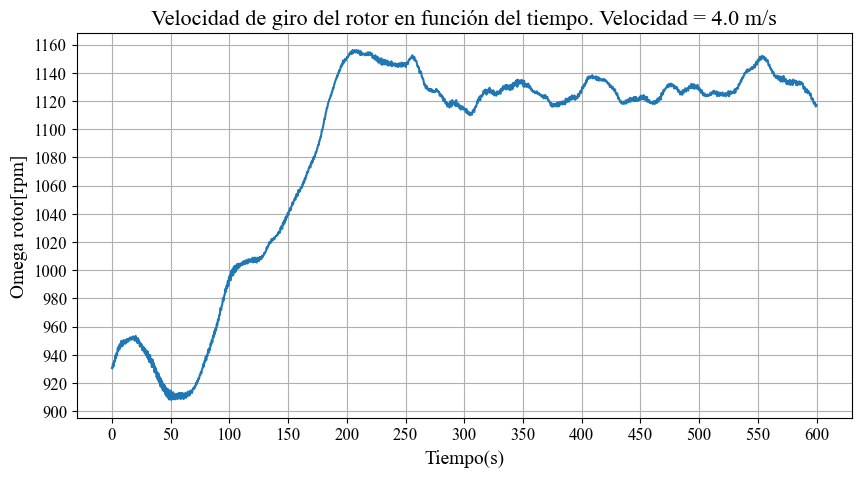

In [ ]:
var =GenSpeed
#var = RotSpeed_1
varName = 'Omega rotor[rpm]'
print(var)
plt.figure(figsize=(10, 5))
plt.plot(Useful_time_1-60, var[start_index:end_index], '-', markersize = 12)
#plt.plot(time, var, '-', markersize = 12)
plt.xlabel('Tiempo(s)')
plt.title(f'Velocidad de giro del rotor en función del tiempo. Velocidad = {U} m/s')
plt.ylabel(varName)
plt.grid()
#plt.xlim(290,325)
#plt.xlim(2000,2090)
plt.locator_params(axis='both', nbins=15)
filename = f'RotSpeed_{model}{tech}_{U}_mas_zoom.png'
file_path = os.path.join(directorio_save, filename)
#plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
plt.show()

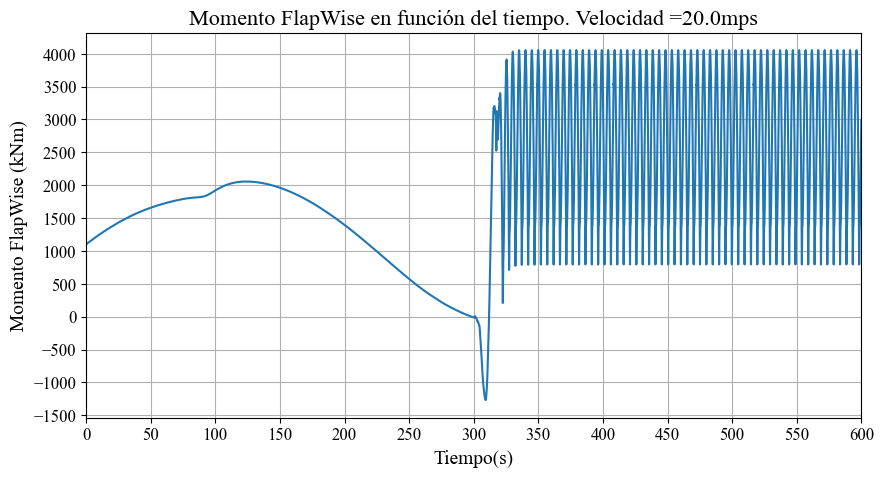

In [ ]:
var = Flapwise1
varName = 'Momento FlapWise (kNm)'

plt.figure(figsize=(10, 5))
plt.plot(Useful_time_1-60, var[start_index:end_index], '-', markersize = 12)
plt.xlabel('Tiempo(s)')
plt.title(f'Momento FlapWise en función del tiempo. Velocidad ={U}mps')
plt.ylabel(varName)
plt.grid()
#plt.ylim(-3000,7000)
plt.xlim(0,600)
plt.locator_params(axis='both', nbins=15)
filename = 'FlapWise_'+ model+ tech +'_'+U+'.png'
directorio_save = f'C:/Users/fgarchitorena/Proyectos de investigacion/FSE_Incercia Sintética/Informe_UTE_DLCs/Imagenes_DLCs_2/Series_temporales_post_pro//{U}'# Cambia esto a la ruta deseada
file_path = os.path.join(directorio_save, filename)
plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
plt.show()

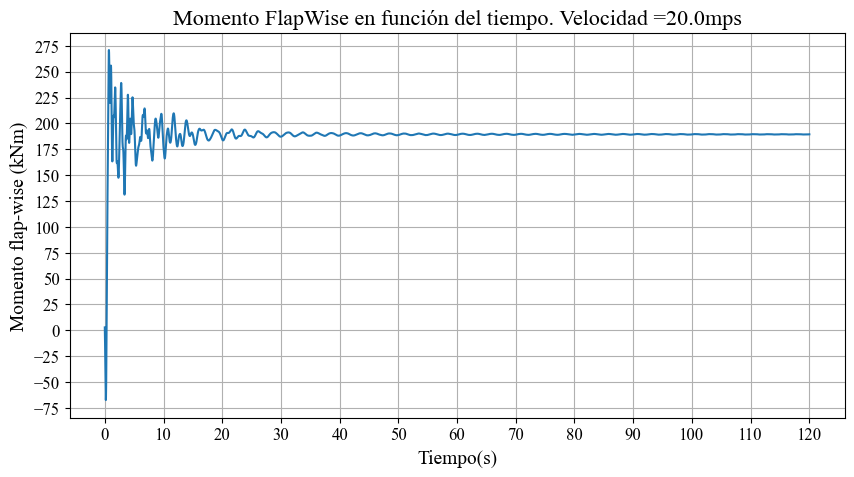

In [ ]:
var = Flapwise1
varName = 'Momento flap-wise (kNm)'

plt.figure(figsize=(10, 5))
plt.plot(time, var, '-', markersize = 12)
plt.xlabel('Tiempo(s)')
plt.title(f'Momento FlapWise en función del tiempo. Velocidad ={U}mps')
plt.ylabel(varName)
plt.grid()
#plt.xlim(0,300)
plt.locator_params(axis='both', nbins=15)
filename = 'FlapWise_'+ model+ tech +U+'.png'
file_path = os.path.join(directorio_save, filename)
#plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
plt.show()

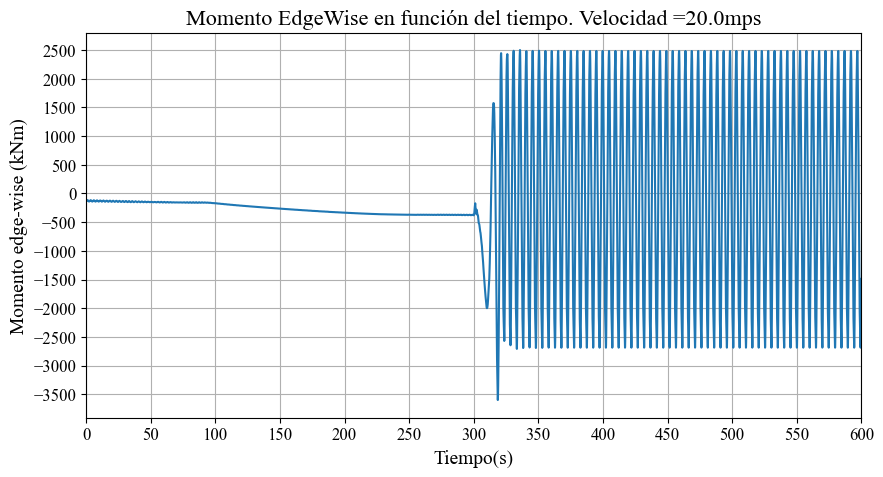

In [ ]:
var = Edgewise_1
varName = 'Momento edge-wise (kNm)'

plt.figure(figsize=(10, 5))
plt.plot(Useful_time_1-60, var[start_index:end_index], '-', markersize = 12)
plt.xlabel('Tiempo(s)')
plt.title(f'Momento EdgeWise en función del tiempo. Velocidad ={U}mps')
plt.ylabel(varName)
plt.grid()
plt.xlim(0,600)
plt.locator_params(axis='both', nbins=15)
filename = 'EdgeWise_'+ model+ tech+'_'+U+'.png'
file_path = os.path.join(directorio_save, filename)
plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
plt.show()

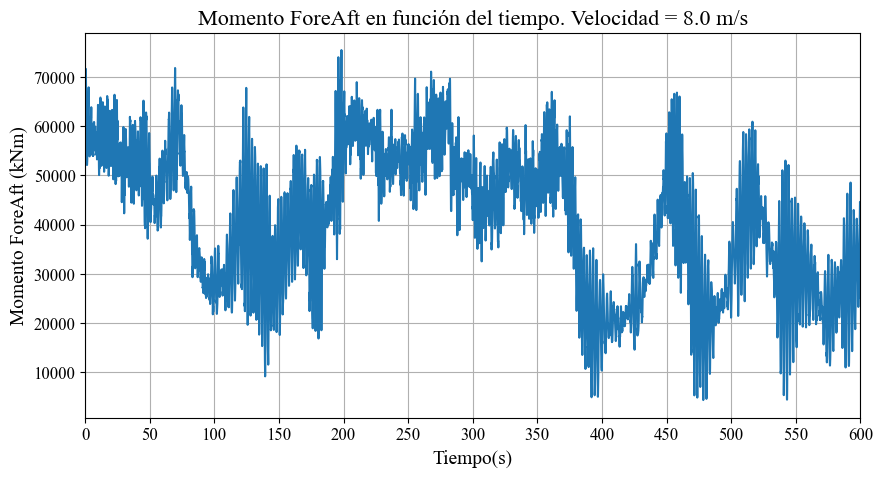

In [ ]:
var = Foreaft1
varName = 'Momento ForeAft (kNm)'

plt.figure(figsize=(10, 5))
plt.plot(Useful_time_1-60, var[start_index:end_index], '-', markersize = 12)
plt.xlabel('Tiempo(s)')
plt.title(f'Momento ForeAft en función del tiempo. Velocidad = {U} m/s')
plt.ylabel(varName)
plt.grid()
#plt.ylim(25000,28000)
plt.xlim(0,600)
plt.locator_params(axis='both', nbins=15)
filename = 'Foreaft_'+ model +tech +'_'+U+'_zoom.png'
file_path = os.path.join(directorio_save, filename)
#plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
plt.show()

660.0
-12692.437625398537


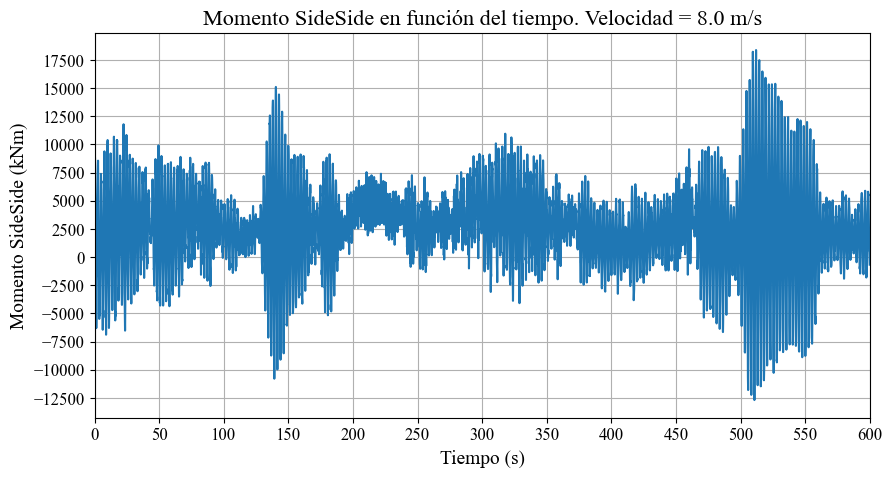

In [ ]:
var = SideSide1
varName = 'Momento SideSide (kNm)'
print(Useful_time_1[len(Useful_time_1)-1])
plt.figure(figsize=(10, 5))
plt.plot(Useful_time_1-60, var[start_index:end_index], '-', markersize = 12)
plt.xlabel('Tiempo (s)')
plt.title(f'Momento SideSide en función del tiempo. Velocidad = {U} m/s')
plt.ylabel(varName)
plt.grid()
plt.xlim(0,600)
#plt.ylim(-4200,12000)
plt.locator_params(axis='both', nbins=15)
filename = 'SideSide_'+ model+tech+'_'+U+'_zoom.png'
file_path = os.path.join(directorio_save, filename)
#plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
print(np.min(var))
plt.show()

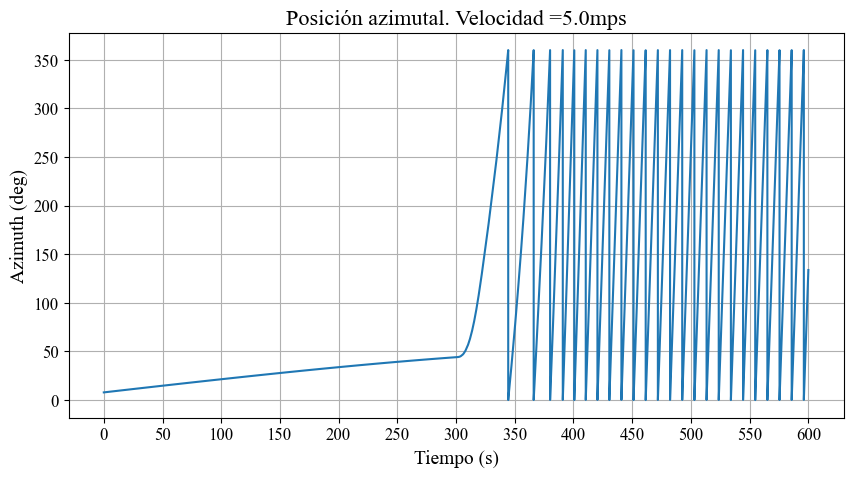

In [ ]:
var = LSSTipPxs
varName = 'Azimuth (deg)'

plt.figure(figsize=(10, 5))
plt.plot(Useful_time_1-60, var[start_index:end_index], '-', markersize = 12)
plt.xlabel('Tiempo (s)')
plt.title(f'Posición azimutal. Velocidad ={U}mps')
plt.ylabel(varName)
plt.grid()
#plt.xlim(0,300)
plt.locator_params(axis='both', nbins=15)
filename = 'SideSide_'+ model+tech+'_'+U+'.png'
file_path = os.path.join(directorio_save, filename)
#plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
plt.show()

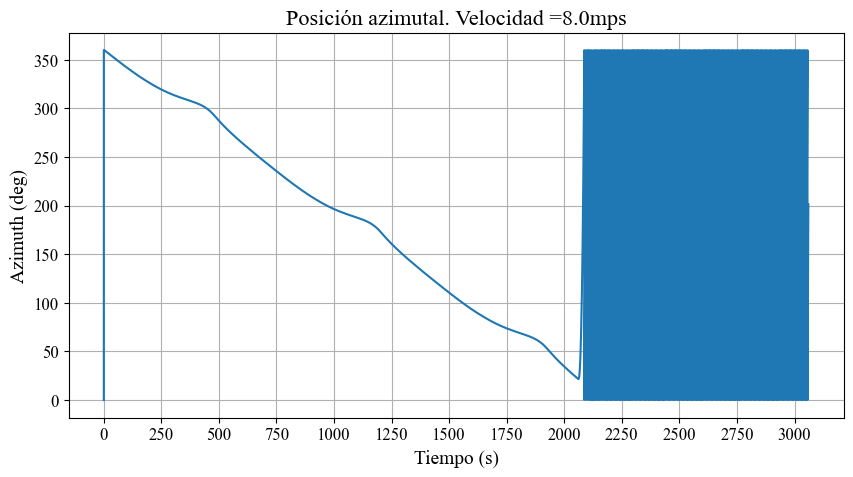

In [ ]:
var = LSSTipPxs
varName = 'Azimuth (deg)'

plt.figure(figsize=(10, 5))
plt.plot(time, var, '-', markersize = 12)
plt.xlabel('Tiempo (s)')
plt.title(f'Posición azimutal. Velocidad ={U}mps')
plt.ylabel(varName)
plt.grid()
#plt.xlim(0,300)
plt.locator_params(axis='both', nbins=15)
filename = 'SideSide_'+ model+tech+'_'+U+'.png'
file_path = os.path.join(directorio_save, filename)
#plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
plt.show()

C:/Users/fgarchitorena/Desktop/OpenFast/DLCs/DLC_4/4p1_SG/20.0


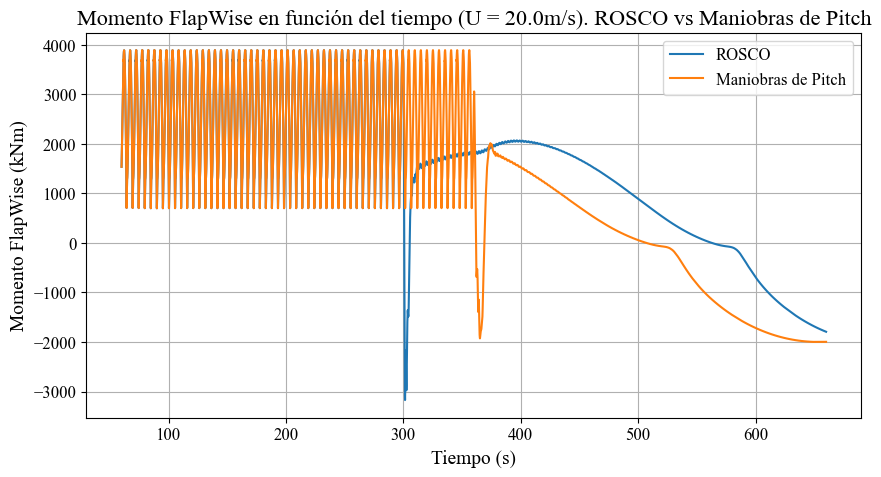

In [ ]:
#Figuras de comparación de modelos DLC 4p1.
model = '4p1'  # flexible; rigid
U = '20.0'
tech_2 = '_SG' #'_Steady_Model_' #'_BEMT_'   #'ROSCO_SDTime'#'ROSCO_TurbS'#'PM_SinGen'
tech_2_f = 'PM' #'Steady_Model' #'BEMT'#'Steady_Model'
#+'_2'
folder = 'C:/Users/fgarchitorena/Desktop/OpenFast/DLCs/DLC_'+ model[0]+'/'+ model+ tech_2 +'/'+ U
print(folder)

#filename = 'IEA-3.4-130-RWT_' + model + tech_2 + U + '.outb'#'_RTS
filename = f'IEA-3.4-130-RWT_{model}_{U}.outb'#'_RTS


df2 = FASTOutputFile(folder +'/' + filename).toDataFrame()
time = np.array(list(df2['Time_[s]']))
 # Define el intervalo de tiempo útil
dt = 0.00625  # Intervalo de tiempo
start_index = int(60 / dt)  # Convierte 60 segundos a índices
end_index = len(time)  # O define hasta dónde quieres seleccionar
Useful_time_2 = time[start_index:end_index]
Flapwise1_2 = np.array(list(df2['RootMyb1_[kN-m]']))
GenPwr_2 = np.array(list(df2['GenPwr_[kW]']))
RotPwr_2 =  np.array(list(df2['RotPwr_[kW]']))
Edgewise_2 = np.array(list(df2['RootMxb1_[kN-m]']))

var_1 = Flapwise1
var_2 = Flapwise1_2
varName = 'Momento FlapWise (kNm)'
label1 = 'ROSCO'
label2 = 'Maniobras de Pitch'

plt.figure(figsize=(10, 5))
plt.plot(Useful_time_1, var_1[start_index:end_index], '-', markersize = 12,label= label1)
plt.plot(Useful_time_2, var_2[start_index:end_index], '-', markersize = 12, label = label2)
plt.xlabel('Tiempo (s)')
plt.title(f'Momento FlapWise en función del tiempo (U = {U}m/s). ROSCO vs Maniobras de Pitch')
#plt.title(f'Momento FlapWise en función del tiempo (U ={U}mps). Dyanmic stall vs Steady Model')
#plt.title(f'Momento FlapWise en función del tiempo (U ={U} m/s). DBEMT vs BEMT')
plt.ylabel(varName)
plt.grid()
plt.legend()
filename = f'Flapwise_{model}{tech_2}vs{tech}_{U}.png'
file_path = os.path.join(directorio_save, filename)
#plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
plt.show()

In [ ]:
filename = 'Flapwise_'+ model+'_'+'SD_vs_SinGen'+'_'+U+'.png'
file_path = os.path.join(directorio_save, filename)
plt.savefig(file_path)
plt.show()

" filename = 'Flapwise_'+ model+'_'+'ROSCOvsPM'+'_'+U+'.png'\nfile_path = os.path.join(directorio_save, filename)\nplt.savefig(file_path)\nplt.show() "

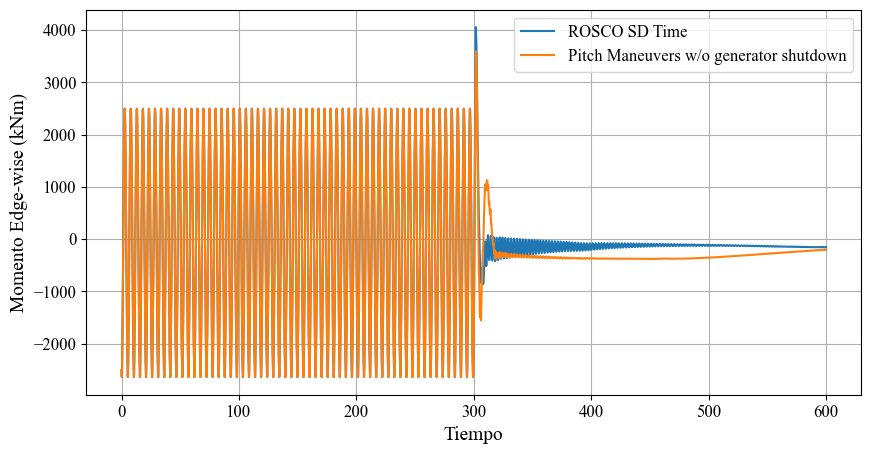

In [ ]:
#Momento Edgewise comparación
var_1 = Edgewise_1
var_2 = Edgewise_2
varName = 'Momento Edge-wise (kNm)'

plt.figure(figsize=(10, 5))
plt.plot(Useful_time-60, var_1[start_index:end_index], '-', markersize = 12,label='ROSCO SD Time')
plt.plot(Useful_time-60, var_2[start_index:end_index], '-', markersize = 12, label = 'Pitch Maneuvers w/o generator shutdown')
#plt.plot(time, var_1, '-', markersize = 12,label='ROSCO User SD Time')
#plt.plot(time, var_2, '-', markersize = 12, label = 'Pitch maneuvers')
plt.xlabel('Tiempo')
#plt.title(f'Momento EdgeWise en función del tiempo (U ={U}mps). ROSCO vs PM')
plt.ylabel(varName)
plt.grid()
plt.legend()
""" filename = 'Flapwise_'+ model+'_'+'ROSCOvsPM'+'_'+U+'.png'
file_path = os.path.join(directorio_save, filename)
plt.savefig(file_path)
plt.show() """

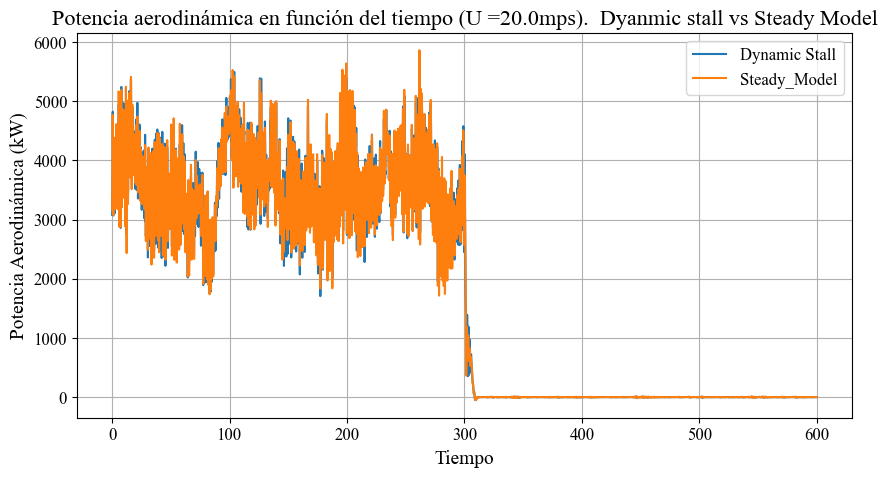

In [ ]:
#Potencia comparación
var_1 = RotPwr_1
var_2 = RotPwr_2
varName = 'Potencia Aerodinámica (kW)'

plt.figure(figsize=(10, 5))
plt.plot(Useful_time-60, var_1[start_index:end_index], '-', markersize = 12,label= label1)
plt.plot(Useful_time-60, var_2[start_index:end_index], '-', markersize = 12, label = tech_2_f)
plt.xlabel('Tiempo')
plt.title(f'Potencia aerodinámica en función del tiempo (U ={U}mps).  Dyanmic stall vs Steady Model')
#plt.title(f'Potencia aerodinámica en función del tiempo (U ={U} m/s).  DBEMT vs BEMT')
plt.ylabel(varName)
plt.grid()
plt.legend()
filename = f'Pot_{model}{tech_2}vs{tech}_{U}.png'
file_path = os.path.join(directorio_save, filename)
plt.savefig(file_path, bbox_inches='tight', pad_inches=0.05)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import subprocess
import os

def check_latex_installation():
    try:
        subprocess.check_output(['latex', '--version'])
        print("LaTeX está correctamente instalado.")
    except FileNotFoundError:
        print("No se encuentra la instalación de LaTeX. Verifica que LaTeX esté instalado y en el PATH.")
    except subprocess.CalledProcessError as e:
        print(f"Error ejecutando LaTeX: {e}")

# Verificar instalación de LaTeX
check_latex_installation()

# Agregar la ruta de LaTeX a la variable PATH
latex_path = r'C:\Users\fgarchitorena\MiKTeX\miktex\bin\x64'  # Reemplaza con la ruta correcta
os.environ['PATH'] = os.environ['PATH'] + ';' + latex_path

# Verifica si la ruta se ha añadido correctamente
print("Rutas en PATH:", os.environ['PATH'])

try:
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": 'Times New Roman',
        "text.latex.preamble": r"\usepackage{amsmath}"
    })

    # Código para graficar
    plt.figure()
    plt.plot([1, 2, 3], [4, 5, 6])
    plt.title("Ejemplo de Gráfico")
    plt.xlabel("Eje X")
    plt.ylabel("Eje Y")
    plt.show()

except RuntimeError as e:
    print(f"Error usando LaTeX: {e}")